<a href="https://colab.research.google.com/github/Joboreh97/Codes-that-function/blob/main/nn_phase_tracker_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NN Phase Tracker — GPU Training on Colab

**Before running:**
1. Runtime → Change runtime type → **T4 GPU** (free tier) or A100 (Colab Pro)
2. Upload `nn_phase_tracker_v7.py` and/or `nn_phase_tracker_v8.py` to your Google Drive
3. Run all cells in order

**What this notebook does:**
- Mounts your Google Drive
- Checks that the GPU is available
- Runs v7 (known SNR) and/or v8 (estimated SNR) training
- Saves results directly to your existing simulation results folder on Drive

In [ ]:
# ── Cell 1: Check GPU ─────────────────────────────────────────────────────
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print('⚠  No GPU detected! Go to Runtime → Change runtime type → GPU')
else:
    print('✓ GPU is available')

Tue Mar 24 23:48:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

In [ ]:
# ── Cell 2: Mount Google Drive ────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print('✓ Drive mounted at /content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Drive mounted at /content/drive


In [ ]:
# ── Cell 3: Set your paths ────────────────────────────────────────────────
import os

# ─── EDIT THESE TWO LINES ─────────────────────────────────────────────────
# This is the path to your results folder inside Google Drive.
# In Windows it was: C:\Users\Office\OneDrive\Dokumente\Masterarbeit_Simulation Results
# On Drive it will be something like:
RESULTS_DIR = '/content/drive/MyDrive/Masterarbeit_Simulation_Results'

# This is where you uploaded the script files on Drive:
SCRIPTS_DIR = '/content/drive/MyDrive/Masterarbeit_Simulation_Results'
# ──────────────────────────────────────────────────────────────────────────

os.makedirs(RESULTS_DIR, exist_ok=True)
print(f'Results dir : {RESULTS_DIR}')
print(f'Scripts dir : {SCRIPTS_DIR}')
print()
print('Files in results dir:')
for f in sorted(os.listdir(RESULTS_DIR)):
    print(f'  {f}')

Results dir : /content/drive/MyDrive/Masterarbeit_Simulation_Results
Scripts dir : /content/drive/MyDrive/Masterarbeit_Simulation_Results

Files in results dir:


In [ ]:
# ── Cell 4: Copy scripts to Colab local storage ───────────────────────────
# Working from local /content is faster than reading/writing Drive directly
# during training. We copy the script here, train, then save back to Drive.

import shutil

for script in ['nn_phase_tracker_v7.py', 'nn_phase_tracker_v8.py']:
    src = os.path.join(SCRIPTS_DIR, script)
    dst = os.path.join('/content', script)
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f'✓ Copied {script} to /content/')
    else:
        print(f'⚠  {script} not found at {src} — upload it to Drive first')

⚠  nn_phase_tracker_v7.py not found at /content/drive/MyDrive/Masterarbeit_Simulation_Results/nn_phase_tracker_v7.py — upload it to Drive first
⚠  nn_phase_tracker_v8.py not found at /content/drive/MyDrive/Masterarbeit_Simulation_Results/nn_phase_tracker_v8.py — upload it to Drive first


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ── Cell 5: Verify TensorFlow sees the GPU ────────────────────────────────
import tensorflow as tf
print(f'TensorFlow version : {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'✓ GPU available: {gpus}')
    # Allow memory growth so TF does not grab all GPU RAM at once
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print('⚠  No GPU found by TensorFlow — check runtime type')

TensorFlow version : 2.19.0
✓ GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ── Cell 6: TRAIN VERSION 7 (known SNR — fair comparison) ─────────────────
# Expected time: ~3-5 hours on T4, ~1-2 hours on A100
#
# The script saves directly to RESULTS_DIR:
#   nn_tracker_v7.weights.h5
#   nn_tracker_v7_const.npy
#   nn_tracker_v7_training.png
#   nn_tracker_v7_comparison.png    (includes Kalman sweep)
#   nn_tracker_v7_results.npz

v7_cmd = [
    'python', '/content/nn_phase_tracker_v7.py',
    '--mode', 'both',
    '--seq_length', '1050',
    '--batch_size', '16',
    '--epochs_s1', '20',
    '--epochs_s2', '80',
    # '--beta_target', '2.5',
    # '--beta_reg_weight', '0.05',
    # '--snr_window', '64',
    '--results_dir', RESULTS_DIR,
    '--filename', 'nn_tracker_v7',


]

print('Starting v7 training...')
print('Command:', ' '.join(v7_cmd))
print()

import subprocess, sys
process = subprocess.Popen(
    v7_cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1
)
for line in process.stdout:
    print(line, end='', flush=True)
process.wait()
print(f'\nv7 process exited with code {process.returncode}')

Streaming output truncated to the last 5000 lines.
  [S1] Ep   5/20  B  48/50  loss=0.00207  ETA: 4m 27s
  [S1] Ep   5/20  B  49/50  loss=0.00206  ETA: 4m 27s
  [S1] Ep   5/20  B  50/50  loss=0.00222  ETA: 4m 26s
  [S1] Ep   5/20  loss=0.00203  elapsed=1m 28s
  [S1] Ep   6/20  B   1/50  loss=0.00178  ETA: 4m 26s
  [S1] Ep   6/20  B   2/50  loss=0.00218  ETA: 4m 26s
  [S1] Ep   6/20  B   3/50  loss=0.00172  ETA: 4m 26s
  [S1] Ep   6/20  B   4/50  loss=0.00218  ETA: 4m 26s
  [S1] Ep   6/20  B   5/50  loss=0.00200  ETA: 4m 26s
  [S1] Ep   6/20  B   6/50  loss=0.00224  ETA: 4m 26s
  [S1] Ep   6/20  B   7/50  loss=0.00184  ETA: 4m 25s
  [S1] Ep   6/20  B   8/50  loss=0.00195  ETA: 4m 25s
  [S1] Ep   6/20  B   9/50  loss=0.00153  ETA: 4m 25s
  [S1] Ep   6/20  B  10/50  loss=0.00191  ETA: 4m 24s
  [S1] Ep   6/20  B  11/50  loss=0.00325  ETA: 4m 23s
  [S1] Ep   6/20  B  12/50  loss=0.00196  ETA: 4m 23s
  [S1] Ep   6/20  B  13/50  loss=0.00191  ETA: 4m 23s
  [S1] Ep   6/20  B  14/50  loss=0.002

In [ ]:
# ── Cell 7: TRAIN VERSION 8 (estimated SNR — conservative comparison) ─────
# Run this after v7 finishes, or in a separate session.
# Expected time: ~3-5 hours on T4

v8_cmd = [
    'python', '/content/nn_phase_tracker_v8.py',
    '--mode', 'both',
    '--seq_length', '1050',
    '--batch_size', '16',
    '--epochs_s1', '20',
    '--epochs_s2', '60',
    '--beta_target', '2.5',
    '--beta_reg_weight', '0.05',
    '--snr_window', '64',
    '--results_dir', RESULTS_DIR,
    '--filename', 'nn_tracker_v8',
]

print('Starting v8 training...')
print('Command:', ' '.join(v8_cmd))
print()

process = subprocess.Popen(
    v8_cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1
)
for line in process.stdout:
    print(line, end='', flush=True)
process.wait()
print(f'\nv8 process exited with code {process.returncode}')

Starting v8 training...
Command: python /content/nn_phase_tracker_v8.py --mode both --seq_length 1050 --batch_size 16 --epochs_s1 20 --epochs_s2 60 --beta_target 2.5 --beta_reg_weight 0.05 --snr_window 64 --results_dir /content/drive/MyDrive/Masterarbeit_Simulation_Results --filename nn_tracker_v8

2026-03-25 00:26:32.482234: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774398392.517529   26965 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774398392.531478   26965 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774398392.559695   26965 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid li

In [ ]:
# ── Cell 8: Check output files ────────────────────────────────────────────
print('Files saved to results dir:')
for f in sorted(os.listdir(RESULTS_DIR)):
    if 'v7' in f or 'v8' in f:
        size = os.path.getsize(os.path.join(RESULTS_DIR, f))
        print(f'  {f:50s}  {size/1024:.1f} KB')

Files saved to results dir:
  nn_tracker_v7.weights.h5                            1479.9 KB
  nn_tracker_v7_comparison.png                        340.7 KB
  nn_tracker_v7_const.npy                             0.6 KB
  nn_tracker_v7_results.npz                           3.9 KB
  nn_tracker_v7_training.png                          126.8 KB
  nn_tracker_v8.weights.h5                            1508.6 KB
  nn_tracker_v8_comparison.png                        386.6 KB
  nn_tracker_v8_const.npy                             0.6 KB
  nn_tracker_v8_results.npz                           3.9 KB
  nn_tracker_v8_training.png                          181.0 KB


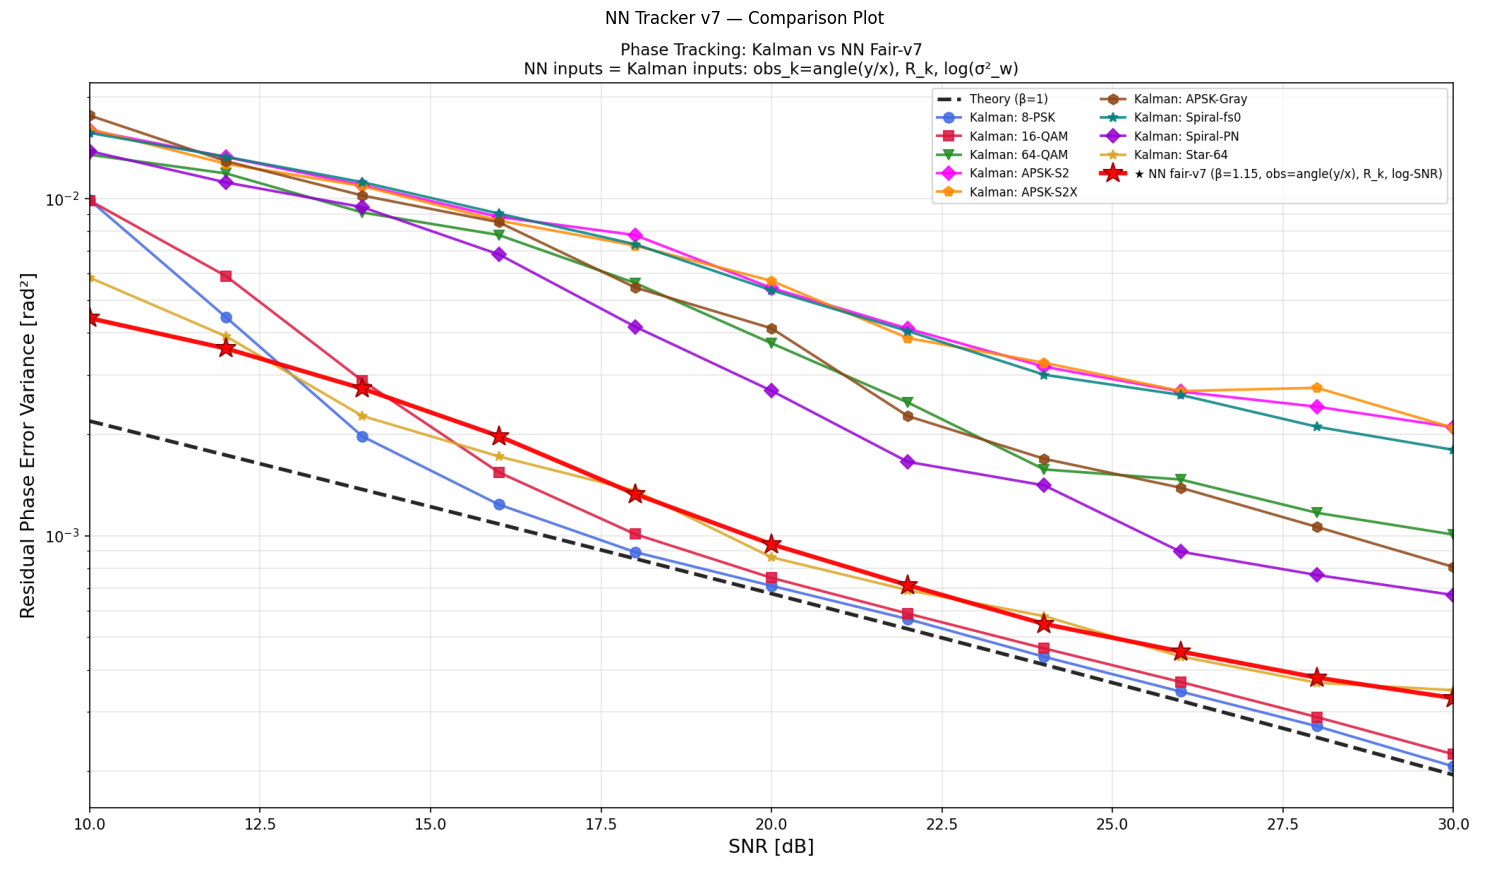

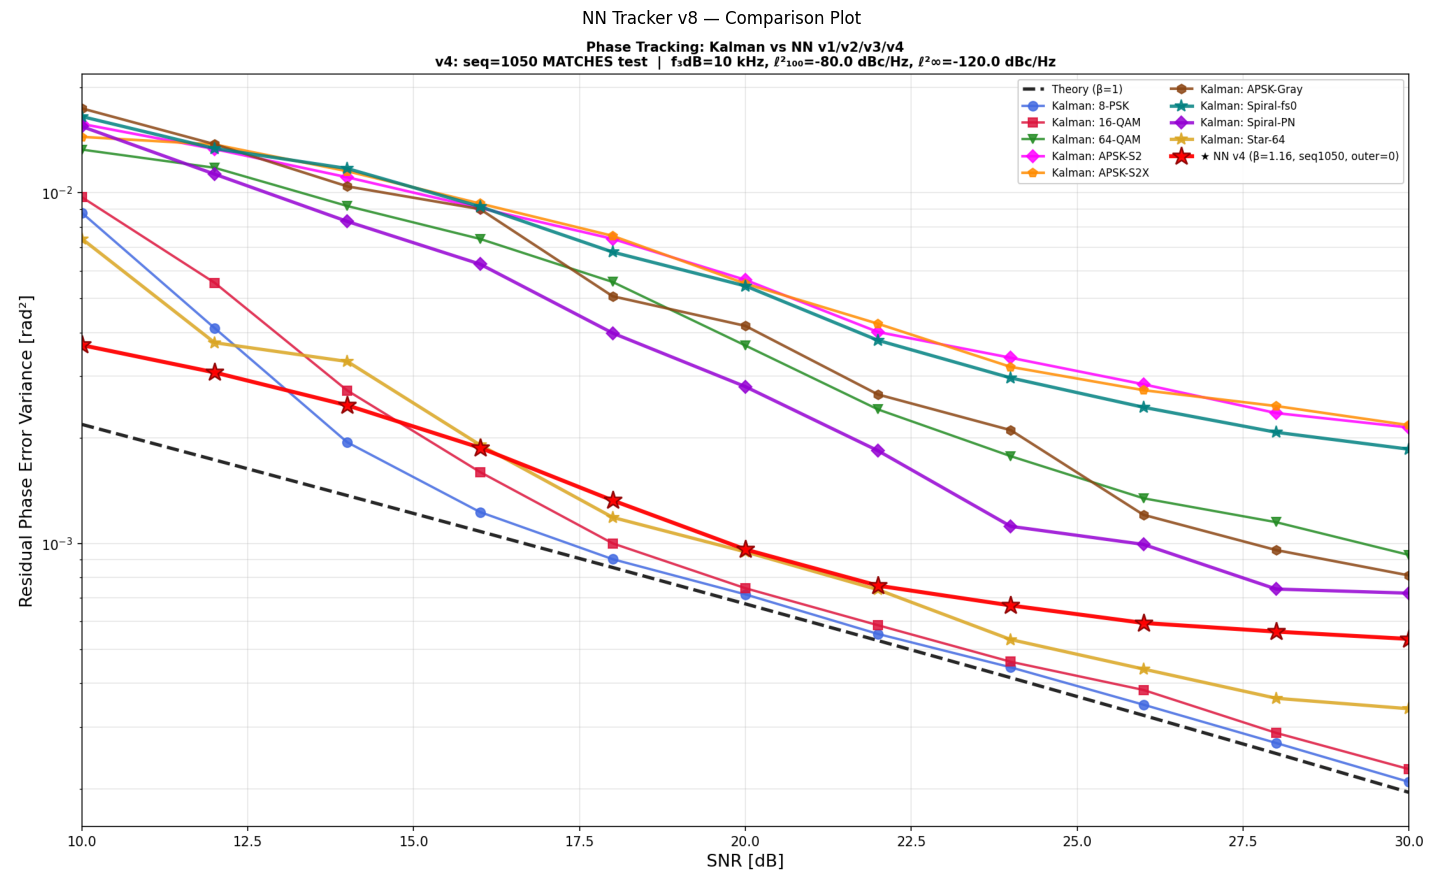

In [ ]:
# ── Cell 9: Show comparison plots inline ──────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

for version in ['v7', 'v8']:
    plot_path = os.path.join(RESULTS_DIR, f'nn_tracker_{version}_comparison.png')
    if os.path.exists(plot_path):
        fig, ax = plt.subplots(figsize=(15, 9))
        img = mpimg.imread(plot_path)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f'NN Tracker {version} — Comparison Plot')
        plt.tight_layout()
        plt.show()
    else:
        print(f'Plot not found for {version}: {plot_path}')

## Notes

**Colab session timeout:** Free Colab disconnects after ~12 hours of inactivity. If training takes longer than this:
- Use Colab Pro (longer sessions) or
- Run v7 and v8 in separate sessions (each is ~3-5h on T4)
- The script saves checkpoints only at the end, so if it crashes mid-training the weights are lost — start that version again

**Keeping the session alive:** Keep the browser tab open and active. You can also use a browser extension like 'Colab Auto-Reconnect' to prevent disconnection.

**Where results go:** Everything saves directly to your Google Drive at `RESULTS_DIR`. When you open the folder on your Windows PC (via OneDrive sync), the files will appear there automatically.

**Batch size:** `--batch_size 16` is safe for T4 (16 GB VRAM). If you get OOM errors, reduce to `--batch_size 8`. If you have an A100, you can increase to `--batch_size 32` for faster training.

**Running only compare (if already trained):** Change `--mode both` to `--mode compare` in the command.